In [2]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from sklearn.datasets import make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1 Prédiction de la réussite des étudiants

Le fichier students.csv contient des données relatives à la prédiction de l’abandon ou de la réussite d’étudiants de l’enseignement supérieur en fin de cursus. Chaque donnée représente un étudiant et contient des informations connues au moment de l’inscription de l’étudiant - parcours scolaire, données démographiques et facteurs socio-économiques.

Pour plus d’information, ce dataset est décrit sur le site de l’UCI.

1. Chargez et préparez les données

In [7]:
df = pd.read_csv('students.csv', sep=';')
y = df['Target']
y = y.map({'Graduate': 0, 'Dropout': 1, 'Enrolled': 2})
X = df.drop('Target', axis =1)

Combien de données et de caractéristiques contient ce dataset ? Quelles sont les proportions de données dans chaque classe ? Les classes sont-elles équilibrées ?

In [4]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [5]:
df.groupby(['Target'])['Target'].count()

Target
Dropout     1421
Enrolled     794
Graduate    2209
Name: Target, dtype: int64

Podemos ver que as classes sao fortemente desequilibradas. A classe "Enrolled" (2) é aproximadamente 2 vezes menor do que a classe "Dropout" (1) e 3 vezes menor do que a classe "Graduate" (0). O desbalanceamento entre classes pode levar a problemas na previsao do modelo.

2. Séparez les données en un jeu d’entraînement et un jeu de test

In [17]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size =0.2, random_state =42)

print(f"Train: {len(y_train)/len(y)*100:.2f}%")
print(f"Test: {len(y_test)/len(y)*100:.2f}%")

Train: 80.00%
Test: 20.00%


3. Standardisez les données

In [18]:
sc = StandardScaler(with_mean=True , with_std=True)
sc = sc.fit(X_train)
Xa_n = sc.transform(X_train)
Xt_n = sc.transform(X_test)

4. Déterminez les hyperparamètres optimaux du SVM à noyaux RBF en utilisant la validation
croisée à 3 folds

In [50]:
svc = SVC(kernel="rbf")
parameters = {'C':[0.1, 1, 10], 'gamma':[0.01, 0.1, 1, 10, 100]}
clf = GridSearchCV(svc, parameters, cv=3)

5. Entrainez un SVM à noyaux RBF avec les hyperparamètres optimaux trouvés sur l’ensemble
d’entraînement

In [42]:
clf.fit(Xa_n, y_train)

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1, 10, 100],
                         'kernel': ['rbf']})

6. Évaluez les performances du modèle sur l’ensemble de test

In [43]:
y_pred = clf.predict(Xt_n)
acc = accuracy_score(y_test, y_pred)
print(f"Accuaracy = {acc*100:.2f}%")

Accuaracy = 76.05%


7. Affichez la matrice de confusion en utilisant confusion_matrix et  confusionMatrixDisplay de Scikit-learn.

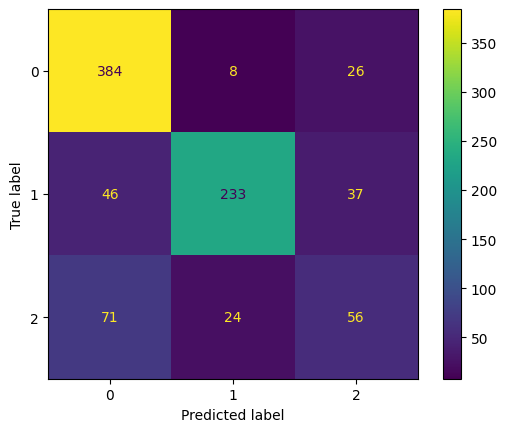

In [44]:
y_pred = clf.predict(Xt_n)
conf = confusion_matrix(y_test , y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf , display_labels=clf.classes_)
disp.plot()
plt.show()

En consultant la documentation, expliquez ce que contient cette matrice et en quoi elle peut être utile.

The confusion matrix shows the number of good predictions in the main diagonal and each case of miss classification in the other cells. That way, it becomes easy to see the classes with the highest number of mistakes.

8. Les valeurs données par la fonction score de Scikit-learn peuvent être calculées à partir des valeurs de la matrice de confusion. Vérifiez-le et expliquez pourquoi ce score n’est pas pertinent pour notre problème.

In [47]:
rig = conf.diagonal().sum()
tot = conf.sum()

score = rig/tot

print(f"Score = {100*score:.2f}%")

Score = 76.05%


O valor do score nao é capaz de mostrar todos os detalhes da previsao que foi realizada. Ele mostra a precisao geral, mas para esta classificacao com mais de 2 classes é importante evidenciar qual a classes que apresenta o maior problema para classificacao, para identificar um metodo de melhoria.

Alem disso, como as classes sao desbalanceadas, este valor pode ser tendencioso, pois como houveram muitos acertos na classe majoritaria o score se apresenta alto, mas na realidade a precisao na classe minoritaria foi bastante insatisfatorio e isto nao esta sendo representado no valor do Score.

9. Que pouvez-vous en conclure sur le comportement des méthodes de SVM à noyaux RBF ?

#### repondre

10. Scikit-learn propose une fonction balanced_accuracy_score qui modifie le score pour tenir compte des classes déséquilibrées. Calculez ce score et comparez-le au score classique.

In [53]:
print(f"Balanced Accuaracy: {balanced_accuracy_score(y_test, y_pred).item()*100:.2f}%")

Balanced Accuaracy: 65.66%


In [48]:
wro = 1-score

balanced = (score+wro)/2

print(balanced)

0.5


11. Ce score est également calculable à partir de la matrice de confusion. Vérifiez-le et donnez votre analyse de ces résultats.

O resultado do Balenced Score é menor do que o Score, este valor representa melhor o resultado, pois o efeito dos erros de classificacao possui um peso maior.

## 2 Bonus : Recommencez avec un noyau polynomial
En guise d’exercice bonus, reprenez les questions de l’exercice précédent en remplaçant le noyau RBF par un noyau polynomial.

GridSearchCV(cv=3, estimator=SVC(kernel='poly'),
             param_grid={'C': [0.1, 1, 10], 'degree': [1, 2, 3, 4, 5]})
Accuaracy = 75.25%


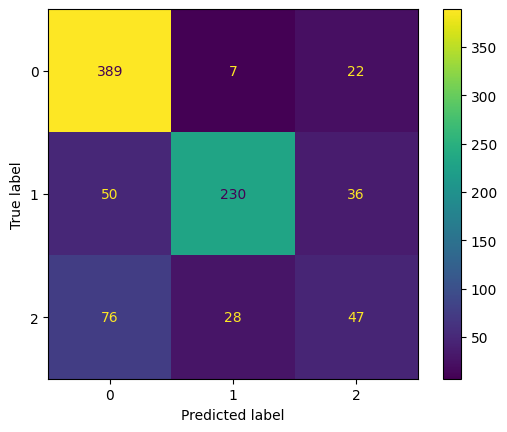

In [52]:
svc = SVC(kernel="poly")
parameters = {'C':[0.1, 1, 10], 'degree':[1, 2, 3, 4, 5]}
clf = GridSearchCV(svc, parameters, cv=3)

clf.fit(Xa_n, y_train)

y_pred = clf.predict(Xt_n)
acc = accuracy_score(y_test, y_pred)
print(f"Accuaracy = {acc*100:.2f}%")

y_pred = clf.predict(Xt_n)
conf = confusion_matrix(y_test , y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf , display_labels=clf.classes_)
disp.plot()
plt.show()